In [1]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchaudio
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB
import warnings
warnings.filterwarnings("ignore")

### 1. Setup paths

In [2]:
# Change this to match your Kaggle dataset folder name
DATASET_FOLDER = "/kaggle/input/emo-ta/TamilSER-DB" #Emo-ta
audio_dir = DATASET_FOLDER  # All .wav files are directly here

files = [f for f in os.listdir(audio_dir) if f.endswith(".wav")]
print(f"Total audio files found: {len(files)}")

Total audio files found: 936


In [3]:
TESS_FOLDER = "/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data" 

# Find all .wav files (recursive in case of nested subfolders)
from pathlib import Path
tess_files = list(Path(TESS_FOLDER).rglob("*.wav"))
print(f"Total TESS audio files found: {len(tess_files)}")  # Should be ~2800

Total TESS audio files found: 2800


In [4]:
RAVDESS_FOLDER = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24"

ravdess_files = list(Path(RAVDESS_FOLDER).rglob("*.wav"))
print(f"Total RAVDESS audio files found: {len(ravdess_files)}")  # Should be 1440

Total RAVDESS audio files found: 1440


# EMO-TA
### 2. Parse labels from filenames

In [5]:
# Filename format: <spkID>_<senID>_<emo[:3]>.wav
# emo codes: ang=angry, hap=happy, sad=sad, fea=fear, neu=neutral

emo_map = {
    "ang": "angry",
    "hap": "happy",
    "sad": "sad",
    "fea": "fear",
    "neu": "neutral"
}

data = []
for f in files:
    parts = f.replace(".wav", "").split("_")
    if len(parts) != 3:
        print(f"Skipping irregular filename: {f}")
        continue
    spk_id = parts[0]
    sen_id = parts[1]
    emo_code = parts[2]
    emotion = emo_map.get(emo_code, "unknown")
    if emotion == "unknown":
        print(f"Unknown emotion code in {f}")
    data.append({"filename": f, "speaker_id": spk_id, "emotion": emotion})

df = pd.DataFrame(data)
print(df.head())

        filename speaker_id  emotion
0  11_14_sad.wav         11      sad
1  04_04_sad.wav         04      sad
2  01_05_neu.wav         01  neutral
3  16_18_sad.wav         16      sad
4  21_13_fea.wav         21     fear


### 3. Exploratory Data Analysis (EDA)

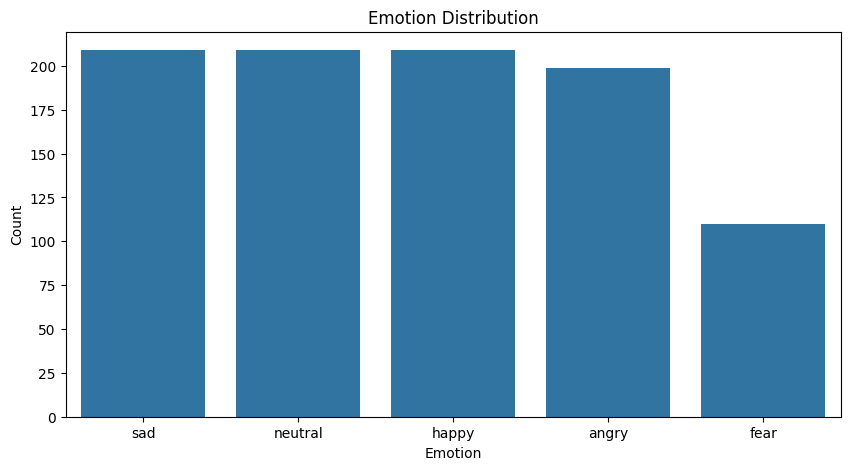

Emotion counts:
 emotion
sad        209
neutral    209
happy      209
angry      199
fear       110
Name: count, dtype: int64


In [6]:
# Emotion distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="emotion", order=df["emotion"].value_counts().index)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

print("Emotion counts:\n", df["emotion"].value_counts())

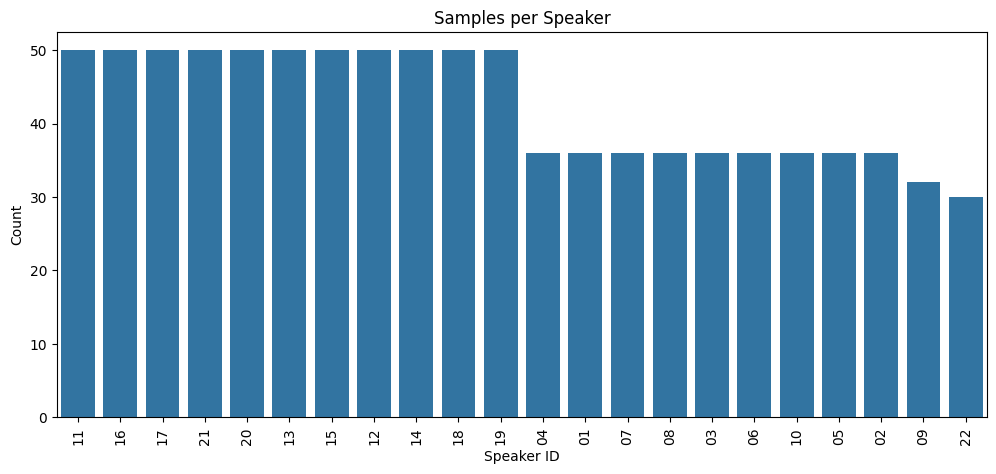

Number of unique speakers: 22


In [7]:
# Speaker distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="speaker_id", order=df["speaker_id"].value_counts().index)
plt.title("Samples per Speaker")
plt.xlabel("Speaker ID")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

print("Number of unique speakers:", df["speaker_id"].nunique())

In [8]:
# Compute durations
durations = []
sample_paths = [os.path.join(audio_dir, f) for f in df["filename"]]

for path in sample_paths:
    dur = librosa.get_duration(path=path)
    durations.append(dur)

df["duration"] = durations

print("Duration statistics:")
print(df["duration"].describe())

Duration statistics:
count    936.000000
mean       2.784571
std        0.687262
min        1.057833
25%        2.272268
50%        2.709333
75%        3.184827
max        6.400000
Name: duration, dtype: float64


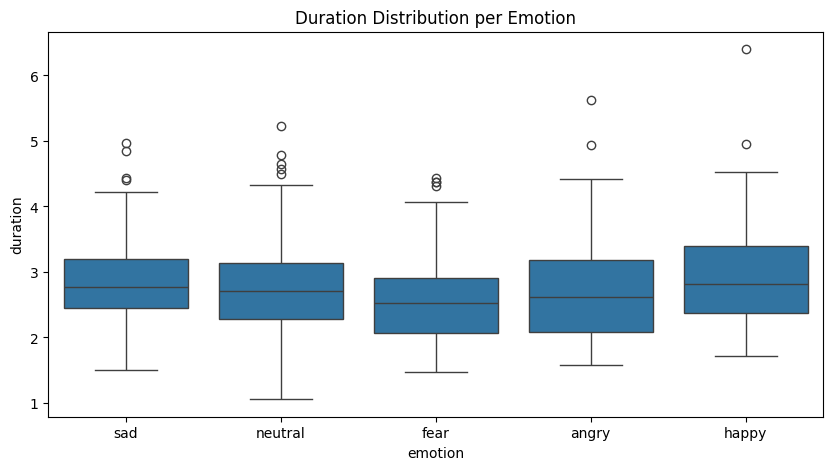

In [9]:
# Duration per emotion
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="emotion", y="duration")
plt.title("Duration Distribution per Emotion")
plt.show()

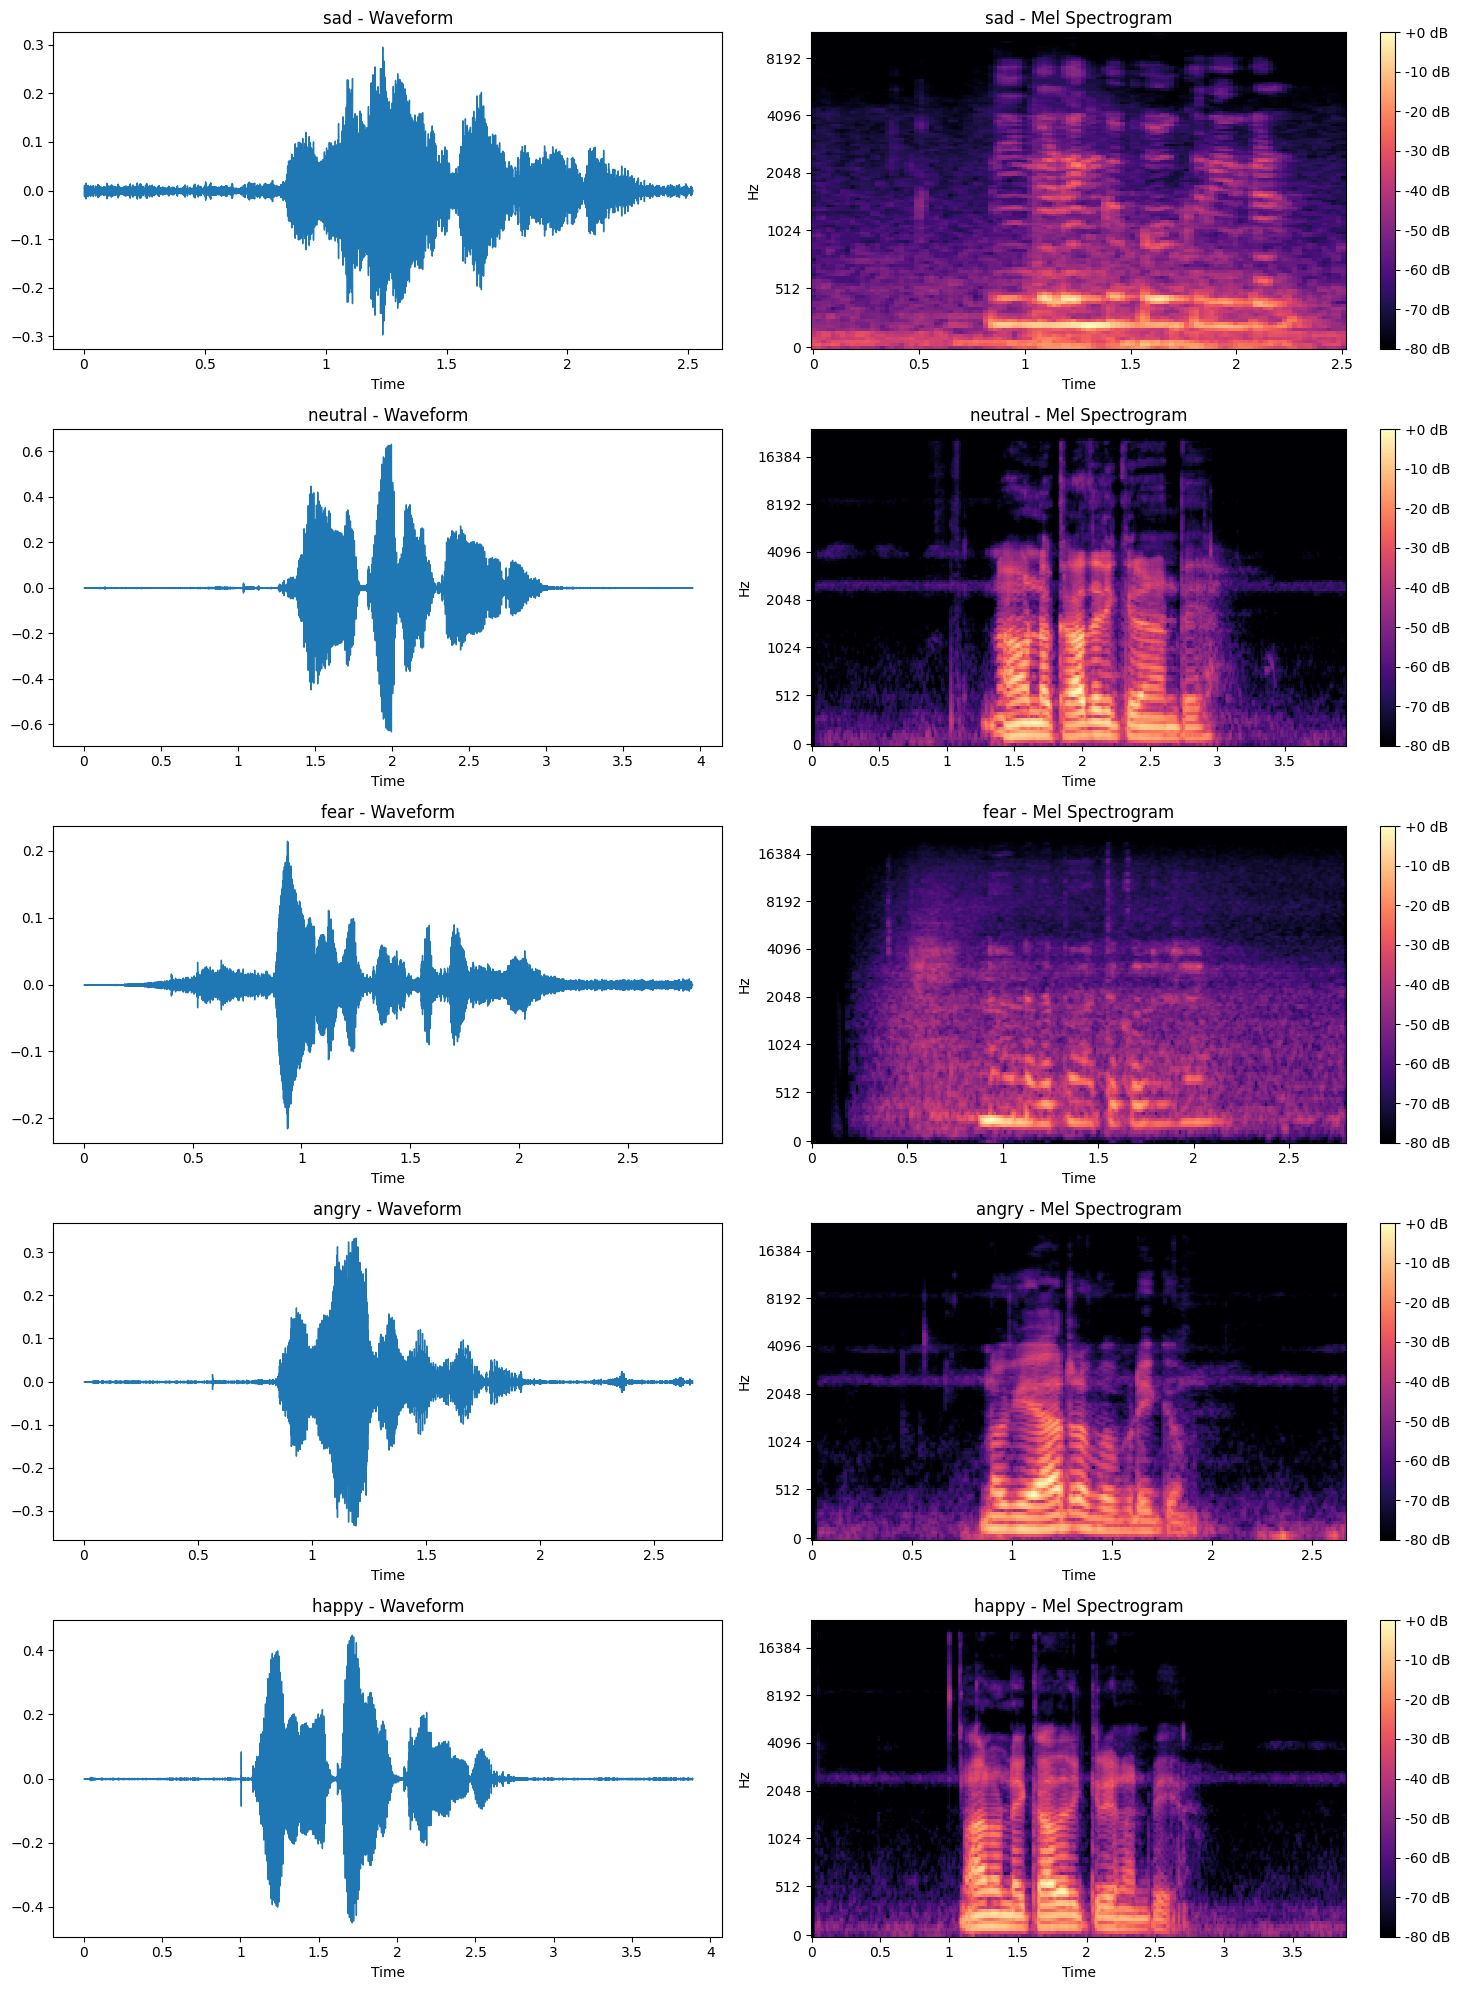

In [10]:
# Waveform and spectrogram examples (one per emotion)
emotions = df["emotion"].unique()
fig, axs = plt.subplots(len(emotions), 2, figsize=(15, 4*len(emotions)))

for idx, emo in enumerate(emotions):
    sample_file = df[df["emotion"] == emo].iloc[0]["filename"]
    path = os.path.join(audio_dir, sample_file)
    y, sr = librosa.load(path, sr=None)
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axs[idx, 0])
    axs[idx, 0].set_title(f"{emo} - Waveform")
    
    # Mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, ax=axs[idx, 1])
    axs[idx, 1].set_title(f"{emo} - Mel Spectrogram")
    fig.colorbar(img, ax=axs[idx, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

### 4. Preprocessing: Log-Mel Spectrogram Extraction

In [11]:
# Parameters (tune as needed)
SAMPLE_RATE = 22050  # Common for speech; change if your files differ
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
FIXED_LENGTH_SEC = 4  # Pad/truncate to 4 seconds (adjust based on your durations)

mel_transform = MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)
db_transform = AmplitudeToDB()

class EmoTaDataset(Dataset):
    def __init__(self, df, audio_dir, transform=None):
        self.df = df
        self.audio_dir = audio_dir
        self.transform = transform
        self.label_to_idx = {label: idx for idx, label in enumerate(sorted(df["emotion"].unique()))}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.audio_dir, row["filename"])
        waveform, sr = torchaudio.load(path)
        
        # Resample if needed
        if sr != SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(sr, SAMPLE_RATE)
            waveform = resampler(waveform)
        
        waveform = waveform.mean(dim=0)  # Convert to mono if stereo
        
        # Fixed length
        target_samples = SAMPLE_RATE * FIXED_LENGTH_SEC
        if waveform.shape[0] > target_samples:
            waveform = waveform[:target_samples]
        else:
            waveform = torch.nn.functional.pad(waveform, (0, target_samples - waveform.shape[0]))
        
        # Mel spectrogram
        mel = mel_transform(waveform)  # (n_mels, time)
        mel_db = db_transform(mel)     # Log scale
        
        label = self.label_to_idx[row["emotion"]]
        
        return mel_db, label

# Create dataset
full_dataset = EmoTaDataset(df, audio_dir)

# Train/val split (80/20, stratified if possible)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

# Test loading one batch
features, labels = next(iter(train_loader))
print("Batch feature shape:", features.shape)  # e.g., (batch, n_mels, time)
print("Batch labels shape:", labels.shape)

Train samples: 748, Val samples: 188
Batch feature shape: torch.Size([32, 128, 173])
Batch labels shape: torch.Size([32])


In [12]:
# Quick cleanliness check (add to your notebook)
print("Unique speaker-sentence pairs:", df[['speaker_id', 'emotion']].duplicated().sum() == 0)  # Should be True
print("Zero/NaN durations:", (df['duration'] <= 0).sum())
print("Very short (<1s):", len(df[df['duration'] < 1]))
print("Very long (>8s):", len(df[df['duration'] > 8]))
print("Load test on all files would succeed as per your DataLoader test")

Unique speaker-sentence pairs: False
Zero/NaN durations: 0
Very short (<1s): 0
Very long (>8s): 0
Load test on all files would succeed as per your DataLoader test


# TESS
### 2. Parse labels from filenames

In [13]:
# Filename pattern: e.g., OAF_back_angry.wav or YAF_calm_neutral.wav
# Speaker: OAF (older), YAF (younger)
# Emotion is the last part before .wav

emo_map_tess = {
    "angry": "angry",
    "disgust": "disgust", 
    "fear": "fear",
    "happy": "happy",
    "sad": "sad",
    "ps": "surprised",      # pleasant surprise → surprised
    "surprise": "surprised",
    "neutral": "neutral"
}

data_tess = []
for path in tess_files:
    filename = path.name
    parts = filename.replace(".wav", "").lower().split("_")
    if len(parts) < 2:
        print(f"Skipping irregular: {filename}")
        continue
    speaker = "OAF" if "oaf" in parts[0] else "YAF"
    emotion_raw = parts[-1]  # last part is emotion
    emotion = emo_map_tess.get(emotion_raw, "unknown")
    if emotion == "unknown":
        print(f"Unknown emotion in {filename}")
    data_tess.append({"filename": str(path), "speaker": speaker, "emotion": emotion})

df_tess = pd.DataFrame(data_tess)
print(df_tess.head())
print("Unique emotions:", df_tess["emotion"].unique())

                                            filename speaker emotion
0  /kaggle/input/toronto-emotional-speech-set-tes...     YAF    fear
1  /kaggle/input/toronto-emotional-speech-set-tes...     YAF    fear
2  /kaggle/input/toronto-emotional-speech-set-tes...     YAF    fear
3  /kaggle/input/toronto-emotional-speech-set-tes...     YAF    fear
4  /kaggle/input/toronto-emotional-speech-set-tes...     YAF    fear
Unique emotions: ['fear' 'angry' 'disgust' 'neutral' 'sad' 'surprised' 'happy']


### 3. EDA

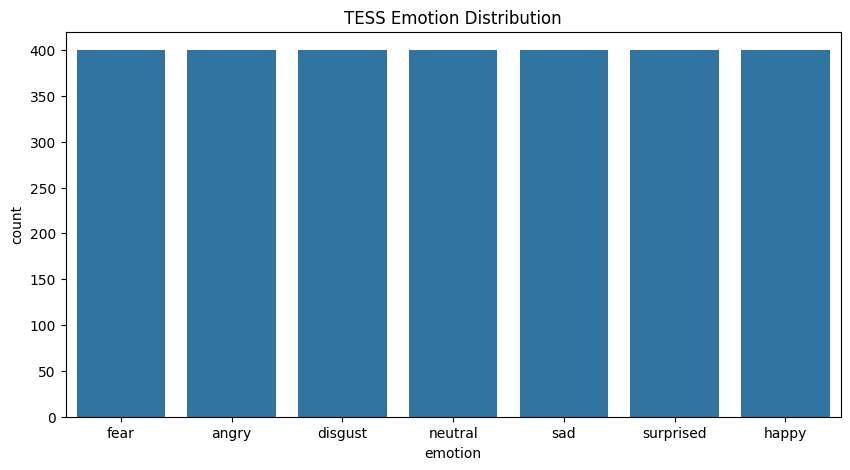

TESS Emotion counts:
 emotion
fear         400
angry        400
disgust      400
neutral      400
sad          400
surprised    400
happy        400
Name: count, dtype: int64


In [14]:
# Emotion distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_tess, x="emotion", order=df_tess["emotion"].value_counts().index)
plt.title("TESS Emotion Distribution")
plt.show()

print("TESS Emotion counts:\n", df_tess["emotion"].value_counts())

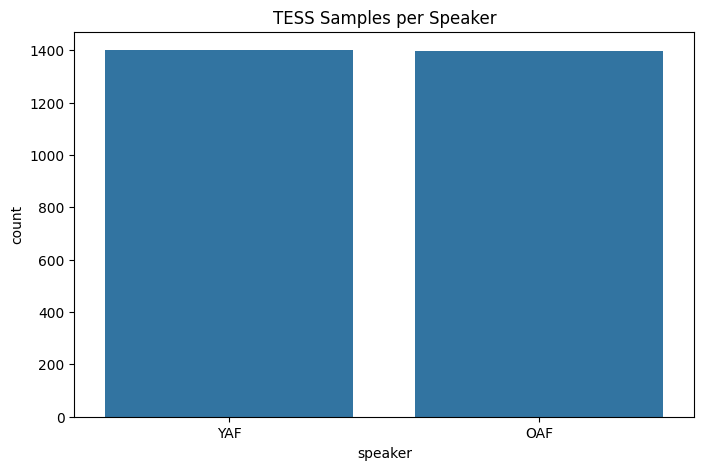

In [15]:
# Speaker distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_tess, x="speaker")
plt.title("TESS Samples per Speaker")
plt.show()

count    2800.000000
mean        2.055126
std         0.320806
min         1.254076
25%         1.836395
50%         2.047903
75%         2.277576
max         2.984804
Name: duration, dtype: float64


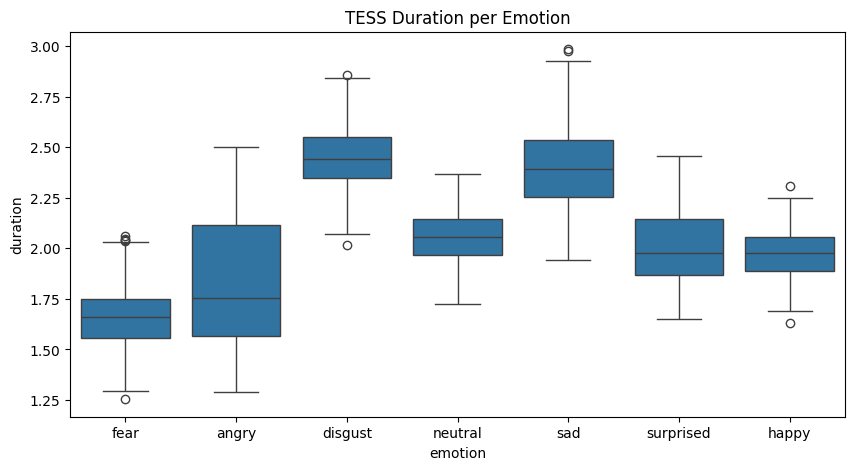

In [16]:
# Durations
durations_tess = []
for path in df_tess["filename"]:
    dur = librosa.get_duration(path=path)
    durations_tess.append(dur)

df_tess["duration"] = durations_tess
print(df_tess["duration"].describe())

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_tess, x="emotion", y="duration")
plt.title("TESS Duration per Emotion")
plt.show()

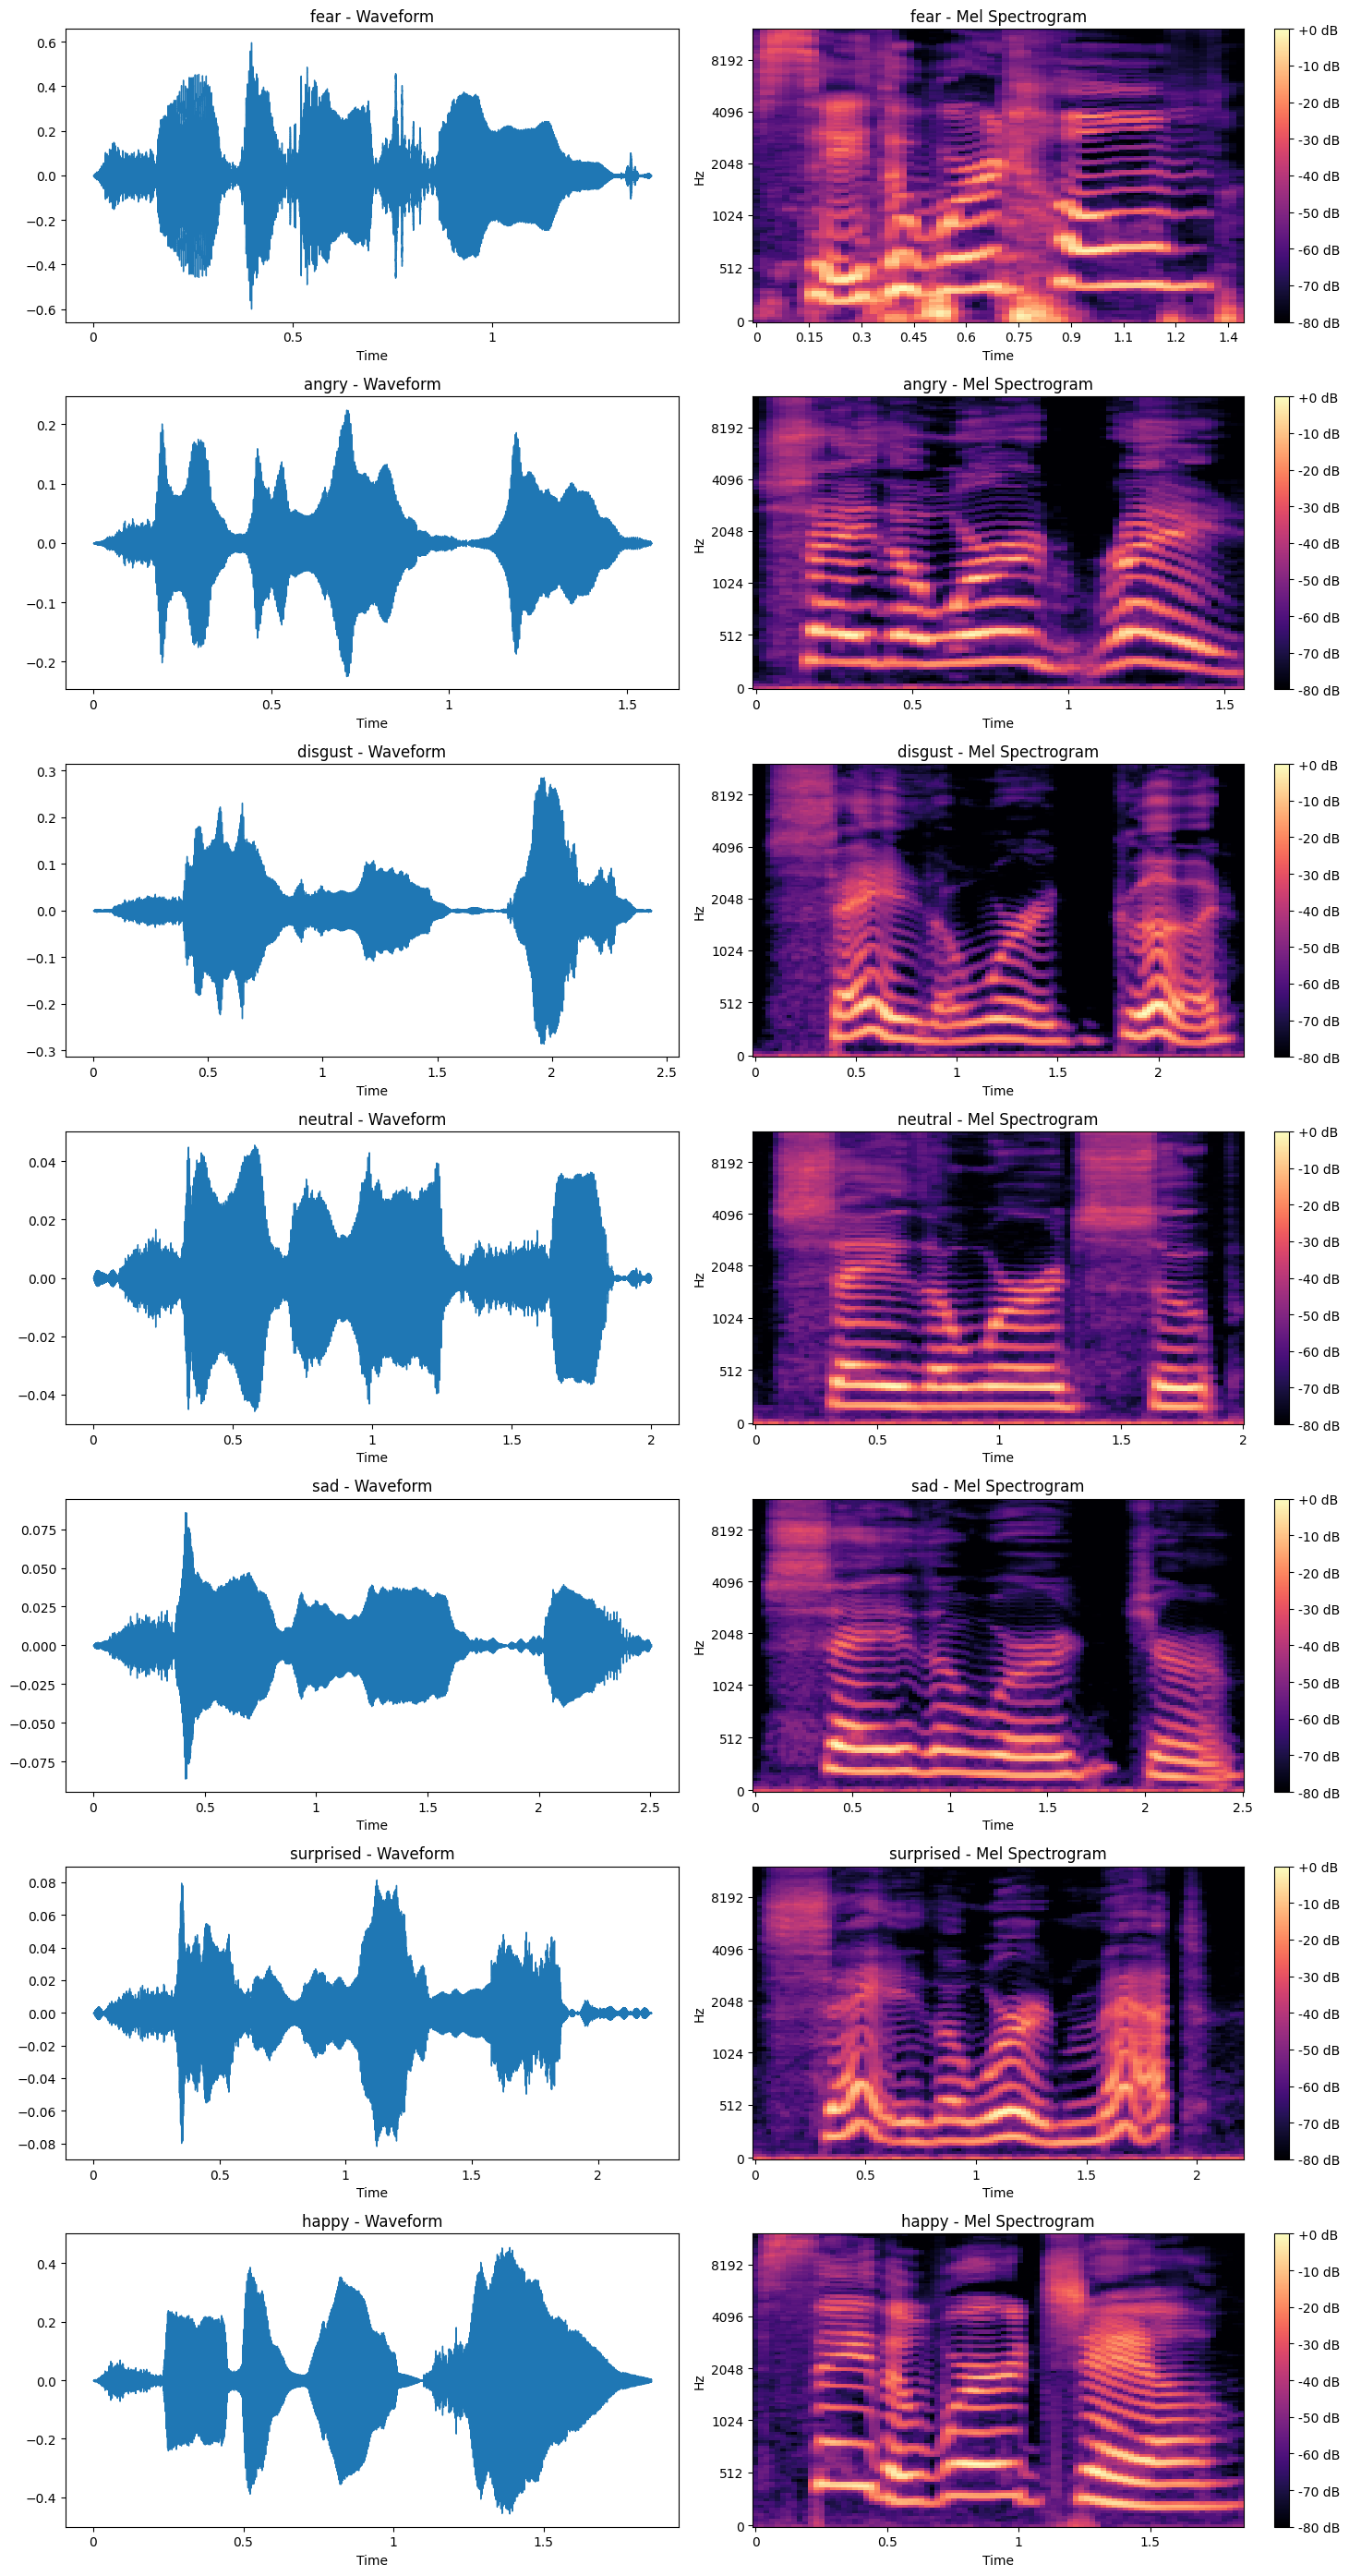

In [17]:
# Example waveforms/spectrograms (one per emotion)
emotions_tess = df_tess["emotion"].unique()
fig, axs = plt.subplots(len(emotions_tess), 2, figsize=(15, 4*len(emotions_tess)))

for idx, emo in enumerate(emotions_tess):
    sample_path = df_tess[df_tess["emotion"] == emo].iloc[0]["filename"]
    y, sr = librosa.load(sample_path, sr=None)
    
    librosa.display.waveshow(y, sr=sr, ax=axs[idx, 0])
    axs[idx, 0].set_title(f"{emo} - Waveform")
    
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, ax=axs[idx, 1])
    axs[idx, 1].set_title(f"{emo} - Mel Spectrogram")
    fig.colorbar(img, ax=axs[idx, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

### 4. Preprocessing

In [18]:
class TESSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.label_to_idx = {label: idx for idx, label in enumerate(sorted(df["emotion"].unique()))}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["filename"]
        waveform, sr = torchaudio.load(path)
        
        if sr != SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(sr, SAMPLE_RATE)
            waveform = resampler(waveform)
        
        waveform = waveform.mean(dim=0)  # mono
        
        target_samples = SAMPLE_RATE * FIXED_LENGTH_SEC
        if waveform.shape[0] > target_samples:
            waveform = waveform[:target_samples]
        else:
            waveform = torch.nn.functional.pad(waveform, (0, target_samples - waveform.shape[0]))
        
        mel = mel_transform(waveform)
        mel_db = db_transform(mel)
        
        label = self.label_to_idx[row["emotion"]]
        
        return mel_db, label

# Reuse the same transforms (or adjust FIXED_LENGTH_SEC if TESS clips are shorter/longer)
tess_dataset = TESSDataset(df_tess)

train_size_t = int(0.8 * len(tess_dataset))
val_size_t = len(tess_dataset) - train_size_t
train_tess, val_tess = random_split(tess_dataset, [train_size_t, val_size_t])

train_loader_tess = DataLoader(train_tess, batch_size=32, shuffle=True)
val_loader_tess = DataLoader(val_tess, batch_size=32, shuffle=False)

print(f"TESS Train: {len(train_tess)}, Val: {len(val_tess)}")
features_t, labels_t = next(iter(train_loader_tess))
print("TESS Batch shape:", features_t.shape)

TESS Train: 2240, Val: 560
TESS Batch shape: torch.Size([32, 128, 173])


# RAVDESS
### 2. Parse labels from filenames

In [19]:
# Filename: 03-01-[emo]-[intens]-[state]-[rep]-[actor].wav
# Emotion codes: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fearful, 07=disgust, 08=surprised

emo_map_rav = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

intensity_map = {"01": "normal", "02": "strong"}  # Note: neutral has no strong

data_rav = []
for path in ravdess_files:
    filename = path.name
    parts = filename.replace(".wav", "").split("-")
    if len(parts) != 7:
        print(f"Skipping irregular: {filename}")
        continue
    emotion_code = parts[2]
    emotion = emo_map_rav.get(emotion_code, "unknown")
    intensity = intensity_map.get(parts[3], "unknown")
    actor = parts[6]
    gender = "male" if int(actor) % 2 == 1 else "female"
    if emotion == "unknown":
        print(f"Unknown emotion in {filename}")
    data_rav.append({
        "filename": str(path),
        "actor": actor,
        "gender": gender,
        "emotion": emotion,
        "intensity": intensity
    })

df_rav = pd.DataFrame(data_rav)
print(df_rav.head())
print("Unique emotions:", df_rav["emotion"].unique())

                                            filename actor  gender    emotion  \
0  /kaggle/input/ravdess-emotional-speech-audio/a...    02  female  surprised   
1  /kaggle/input/ravdess-emotional-speech-audio/a...    02  female    neutral   
2  /kaggle/input/ravdess-emotional-speech-audio/a...    02  female    disgust   
3  /kaggle/input/ravdess-emotional-speech-audio/a...    02  female    disgust   
4  /kaggle/input/ravdess-emotional-speech-audio/a...    02  female    neutral   

  intensity  
0    normal  
1    normal  
2    strong  
3    normal  
4    normal  
Unique emotions: ['surprised' 'neutral' 'disgust' 'fearful' 'sad' 'calm' 'happy' 'angry']


### 3. EDA

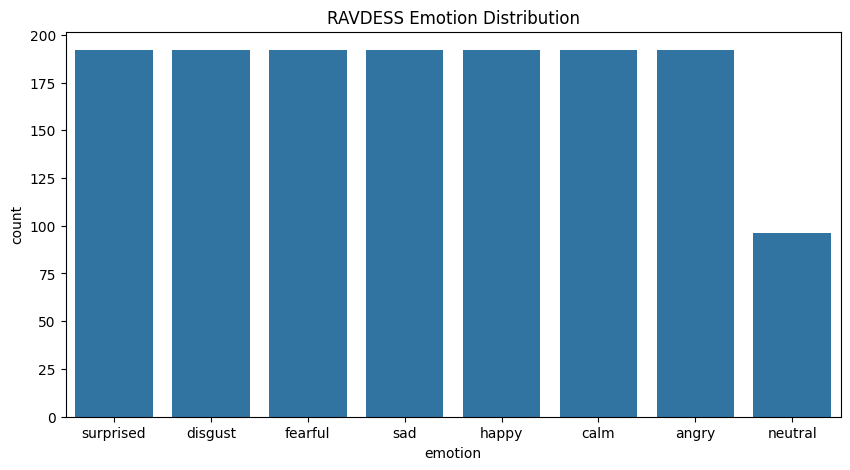

Emotion counts:
 emotion
surprised    192
disgust      192
fearful      192
sad          192
happy        192
calm         192
angry        192
neutral       96
Name: count, dtype: int64


In [20]:
# Emotion distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df_rav, x="emotion", order=df_rav["emotion"].value_counts().index)
plt.title("RAVDESS Emotion Distribution")
plt.show()

print("Emotion counts:\n", df_rav["emotion"].value_counts())

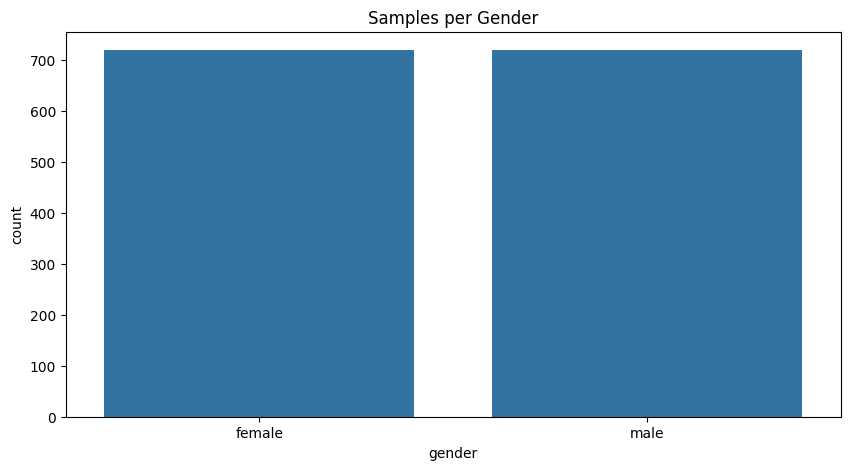

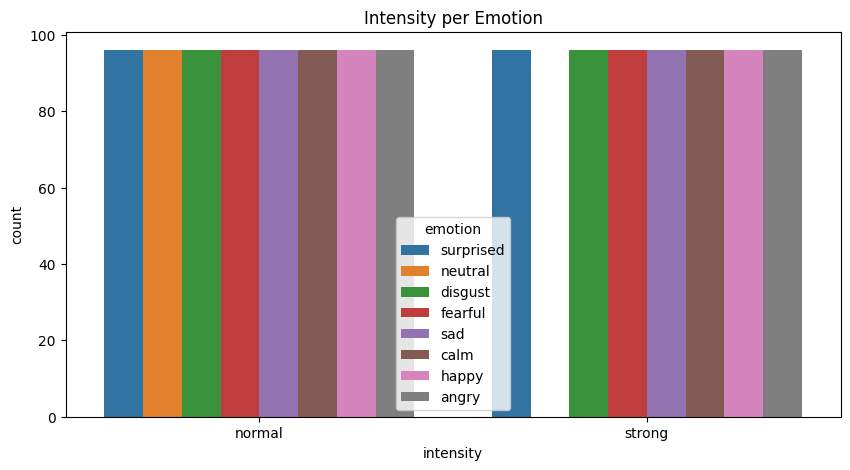

In [21]:
# Gender and intensity
plt.figure(figsize=(10, 5))
sns.countplot(data=df_rav, x="gender")
plt.title("Samples per Gender")
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df_rav, x="intensity", hue="emotion")
plt.title("Intensity per Emotion")
plt.show()

count    1440.000000
mean        3.700665
std         0.336676
min         2.936271
25%         3.470146
50%         3.670333
75%         3.870542
max         5.271937
Name: duration, dtype: float64


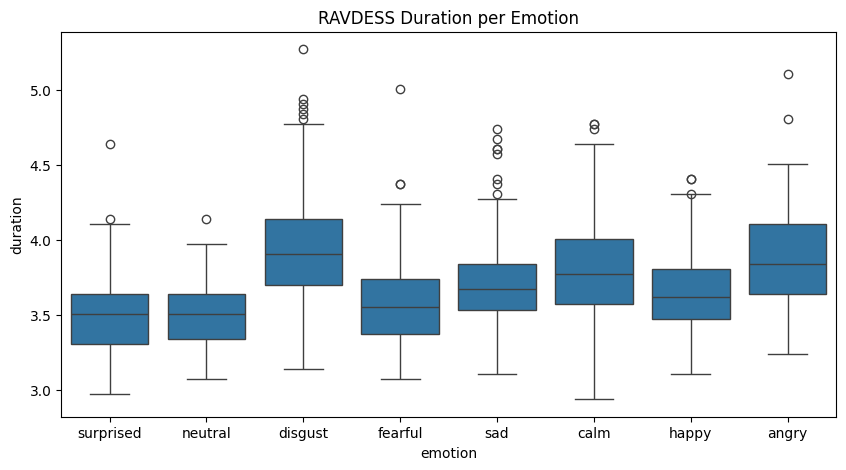

In [22]:
# Durations
durations_rav = [librosa.get_duration(path=p) for p in df_rav["filename"]]
df_rav["duration"] = durations_rav
print(df_rav["duration"].describe())

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_rav, x="emotion", y="duration")
plt.title("RAVDESS Duration per Emotion")
plt.show()

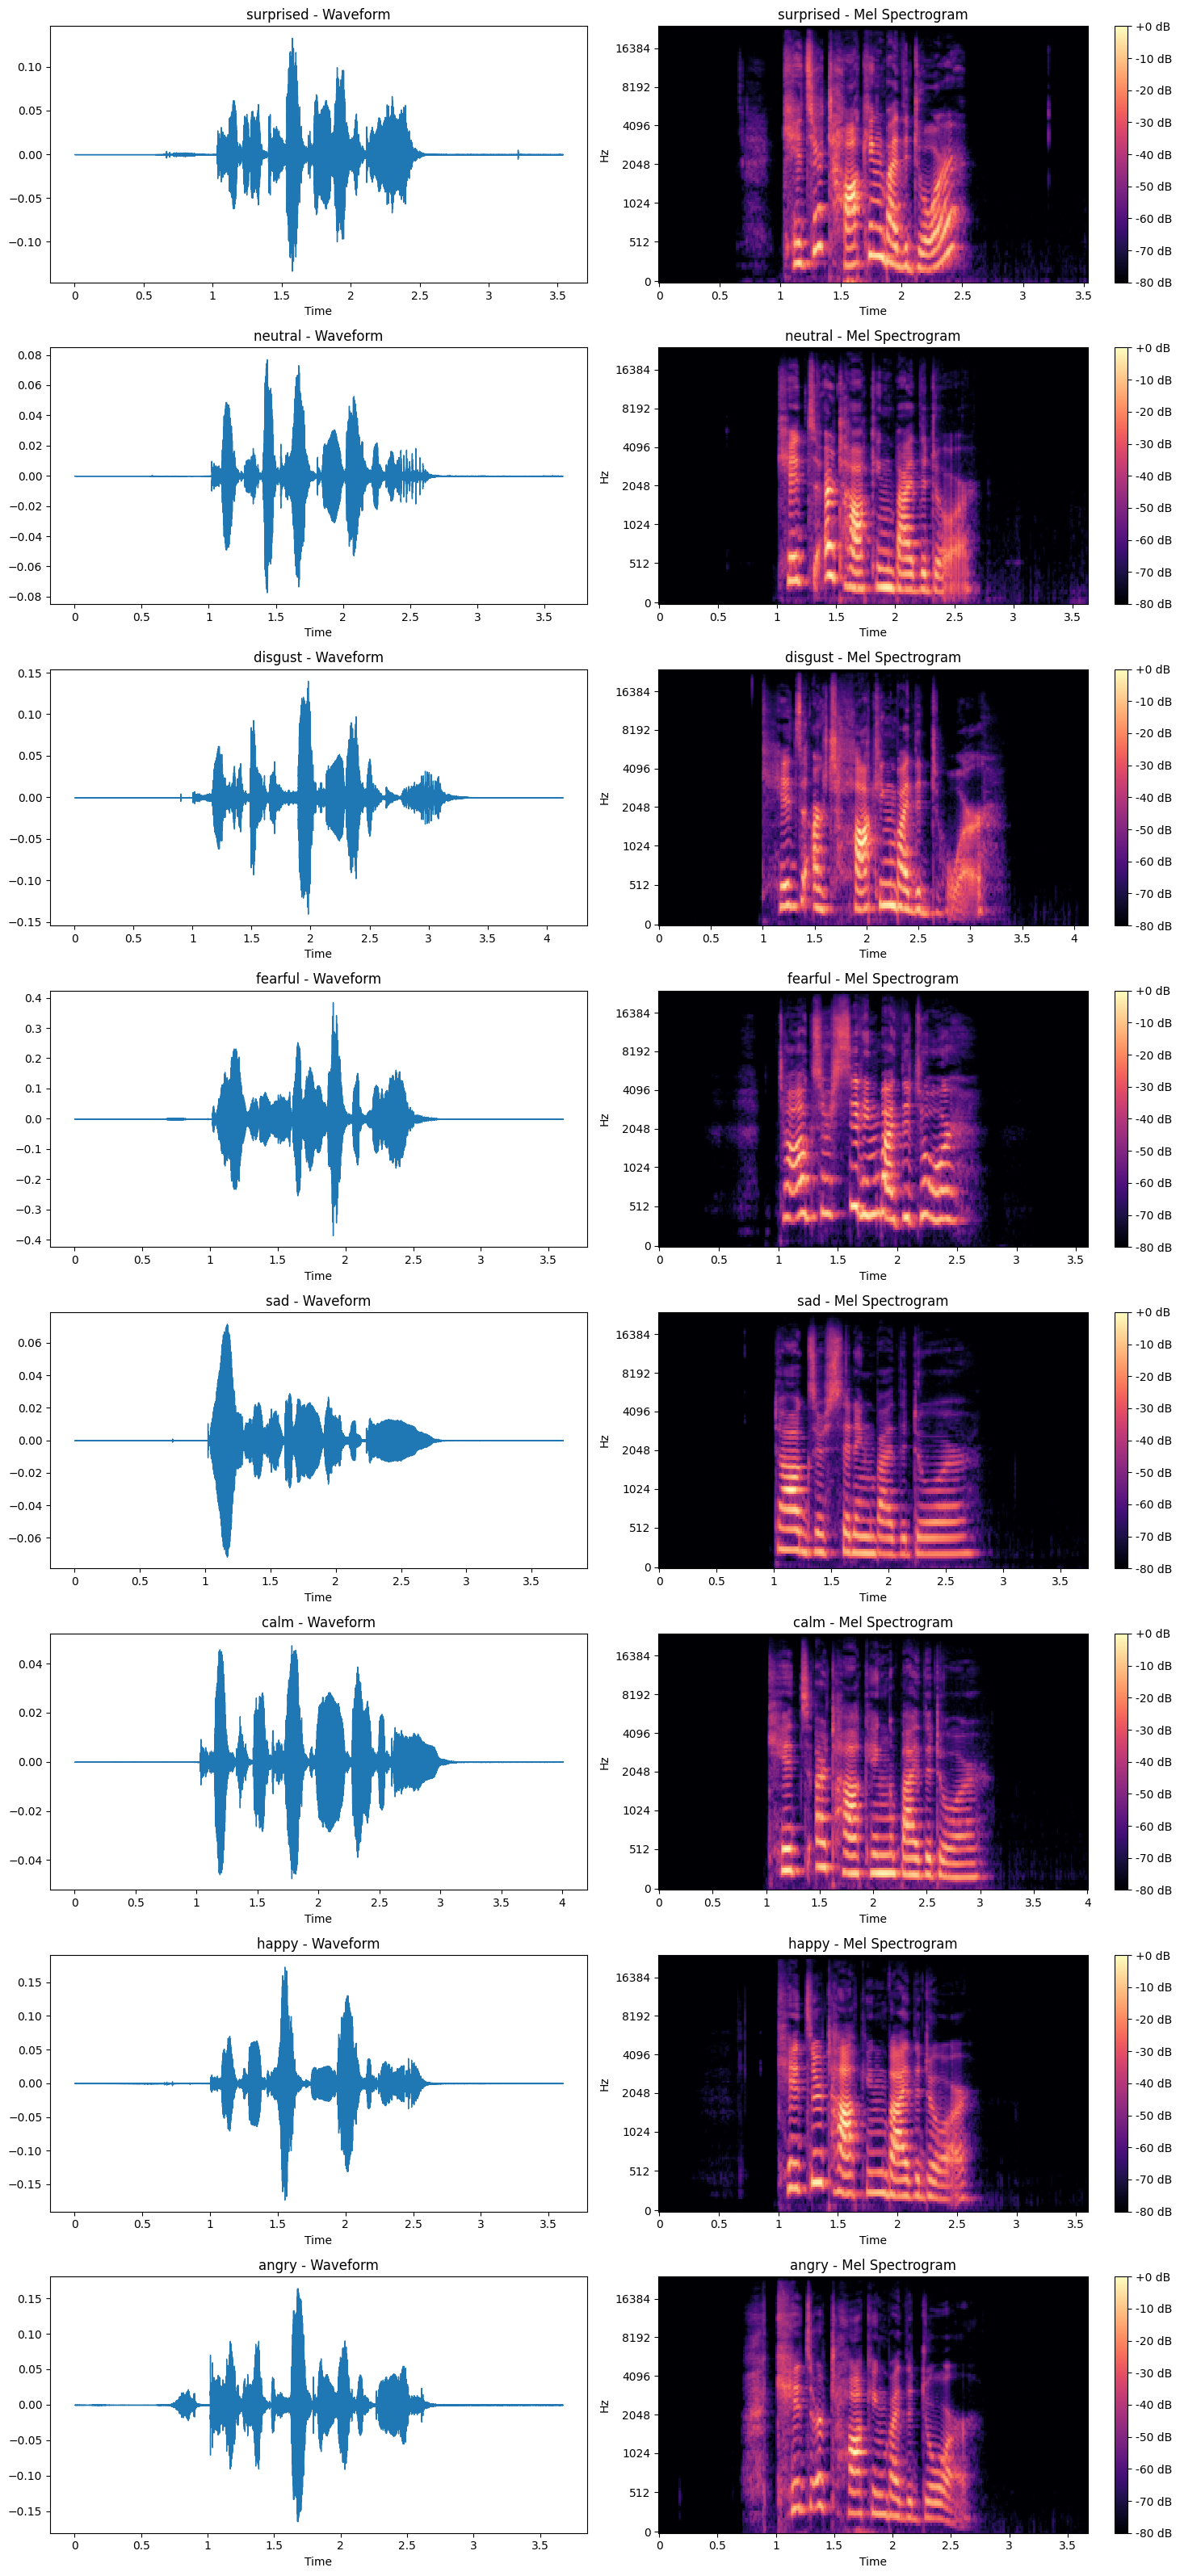

In [23]:
# Example visualizations (one per emotion)
emotions_rav = df_rav["emotion"].unique()
fig, axs = plt.subplots(len(emotions_rav), 2, figsize=(15, 4*len(emotions_rav)))

for idx, emo in enumerate(emotions_rav):
    sample_path = df_rav[df_rav["emotion"] == emo].iloc[0]["filename"]
    y, sr = librosa.load(sample_path, sr=None)
    
    librosa.display.waveshow(y, sr=sr, ax=axs[idx, 0])
    axs[idx, 0].set_title(f"{emo} - Waveform")
    
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, ax=axs[idx, 1])
    axs[idx, 1].set_title(f"{emo} - Mel Spectrogram")
    fig.colorbar(img, ax=axs[idx, 1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

### 4. Preprocessing

In [24]:
class RAVDESSDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.label_to_idx = {label: idx for idx, label in enumerate(sorted(df["emotion"].unique()))}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = row["filename"]
        waveform, sr = torchaudio.load(path)
        
        if sr != SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(sr, SAMPLE_RATE)
            waveform = resampler(waveform)
        
        waveform = waveform.mean(dim=0)  # mono
        
        target_samples = SAMPLE_RATE * FIXED_LENGTH_SEC
        if waveform.shape[0] > target_samples:
            waveform = waveform[:target_samples]
        else:
            waveform = torch.nn.functional.pad(waveform, (0, target_samples - waveform.shape[0]))
        
        mel = mel_transform(waveform)
        mel_db = db_transform(mel)
        
        label = self.label_to_idx[row["emotion"]]
        
        return mel_db, label

ravdess_dataset = RAVDESSDataset(df_rav)

train_size_r = int(0.8 * len(ravdess_dataset))
val_size_r = len(ravdess_dataset) - train_size_r
train_rav, val_rav = random_split(ravdess_dataset, [train_size_r, val_size_r])

train_loader_rav = DataLoader(train_rav, batch_size=32, shuffle=True)
val_loader_rav = DataLoader(val_rav, batch_size=32, shuffle=False)

print(f"RAVDESS Train: {len(train_rav)}, Val: {len(val_rav)}")
features_r, labels_r = next(iter(train_loader_rav))
print("RAVDESS Batch shape:", features_r.shape)

RAVDESS Train: 1152, Val: 288
RAVDESS Batch shape: torch.Size([32, 128, 173])
